<a href="https://colab.research.google.com/github/alessandro-leanza/diffusion-policy-compliant-robots_lesson/blob/main/practice/03_training_pipeline.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Run on Google Colab:** open with the badge above, enable a GPU via **Runtime → Change runtime type → GPU**, then **Runtime → Run all**. The *Setup* cell installs/checks all dependencies.

In [1]:
# --- Setup (run first) ---------------------------------------------------
# Google Colab ships torch, torchvision, numpy, matplotlib, Pillow and tqdm
# pre-installed, so there is nothing extra to install for this notebook.
import torch
print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("No GPU detected. On Colab: Runtime -> Change runtime type -> GPU.")

PyTorch 2.9.1+cu128 | CUDA available: True


# Complete DDPM Training Pipeline from Scratch
**Lecture — Politecnico di Milano**

We build a full Denoising Diffusion Probabilistic Model (DDPM) from scratch:

1. **Dataset** — MNIST digits
2. **Noise schedule** — cosine schedule
3. **Forward process** — closed-form sampling at any $t$
4. **U-Net** — with sinusoidal time embeddings, residual blocks, self-attention
5. **Training loop** — noise prediction with MSE loss
6. **DDPM sampler** — iterative denoising from $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0},\mathbf{I})$

**Reference:** Ho et al., *Denoising Diffusion Probabilistic Models*, NeurIPS 2020.

In [2]:
import math, os, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

torch.manual_seed(42)
np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


In [3]:
# ============================================================
# CONFIGURATION
# ============================================================
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE    = 28          # MNIST image size
CHANNELS    = 1           # grayscale
T_STEPS     = 1000        # diffusion timesteps
BATCH_SIZE  = 128
LR          = 2e-4
NUM_EPOCHS  = 20          # increase to 100+ for publication quality
MODEL_DIM   = 64          # base channel width of U-Net
DATA_DIR    = './data'
SAVE_DIR    = './ddpm_results'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Device  : {DEVICE}')
print(f'Epochs  : {NUM_EPOCHS}  (increase for better quality)')

Device  : cuda
Epochs  : 20  (increase for better quality)


---
## 1. Dataset — MNIST

MNIST is a simple benchmark for generative models: 60 000 grayscale 28×28 images of handwritten digits.

We normalize pixels from $[0,1]$ to $[-1,1]$ to match the assumed zero-mean data distribution.

Failed to download (trying next):
HTTP Error 404: Not Found

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Training samples   : 60,000
Image shape (C,H,W): (1, 28, 28)
Batches per epoch  : 469


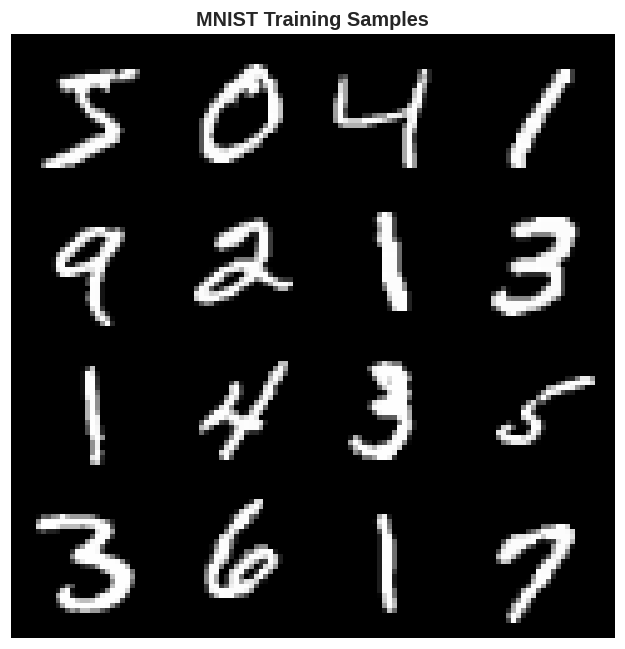

In [4]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))   # [0,1] → [-1,1]
])

train_ds = torchvision.datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f'Training samples   : {len(train_ds):,}')
print(f'Image shape (C,H,W): {tuple(train_ds[0][0].shape)}')
print(f'Batches per epoch  : {len(train_dl)}')

# Visualise a grid of samples
samples = torch.stack([train_ds[i][0] for i in range(16)])
grid = torchvision.utils.make_grid(samples, nrow=4, normalize=True, value_range=(-1, 1))
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
ax.axis('off')
ax.set_title('MNIST Training Samples', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 2. Noise Schedule

We use the **cosine schedule** which keeps $\bar{\alpha}_t$ smooth and avoids abrupt noise at small $t$:
$$\bar{\alpha}_t = \frac{f(t)}{f(0)}, \quad f(t) = \cos^2\!\left(\frac{t/T + s}{1+s}\cdot\frac{\pi}{2}\right)$$

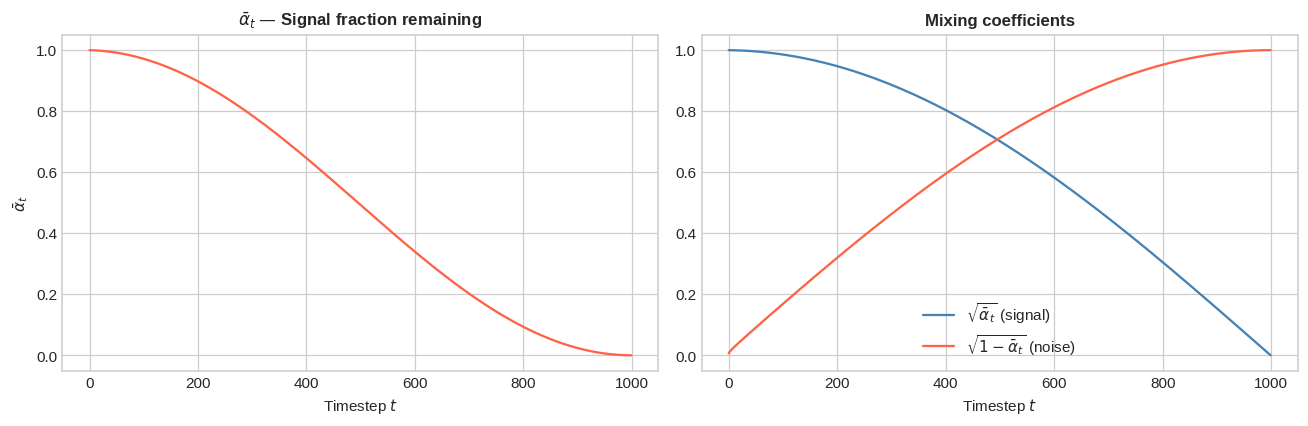

In [5]:
def cosine_beta_schedule(T, s=0.008):
    steps = torch.arange(T + 1, dtype=torch.float64)
    f = torch.cos(((steps / T) + s) / (1 + s) * math.pi / 2) ** 2
    a_bar = f / f[0]
    betas = torch.clamp(1.0 - a_bar[1:] / a_bar[:-1], min=1e-5, max=0.9999)
    return betas.float()

betas             = cosine_beta_schedule(T_STEPS).to(DEVICE)
alphas            = 1.0 - betas
alphas_cumprod    = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_a_bar        = torch.sqrt(alphas_cumprod)
sqrt_one_minus    = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alpha  = torch.sqrt(1.0 / alphas)
posterior_var     = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, shape):
    b = t.shape[0]
    return a.gather(-1, t).reshape(b, *([1] * (len(shape) - 1)))

t_axis = np.arange(T_STEPS)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_axis, alphas_cumprod.cpu(), color='tomato')
axes[0].set_title('$\\bar{\\alpha}_t$ — Signal fraction remaining', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Timestep $t$'); axes[0].set_ylabel('$\\bar{\\alpha}_t$')
axes[1].plot(t_axis, sqrt_a_bar.cpu(), label='$\\sqrt{\\bar\\alpha_t}$ (signal)',  color='steelblue')
axes[1].plot(t_axis, sqrt_one_minus.cpu(), label='$\\sqrt{1-\\bar\\alpha_t}$ (noise)', color='tomato')
axes[1].set_title('Mixing coefficients', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Timestep $t$'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## 3. Forward Process

$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\varepsilon}, \quad \boldsymbol{\varepsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$$

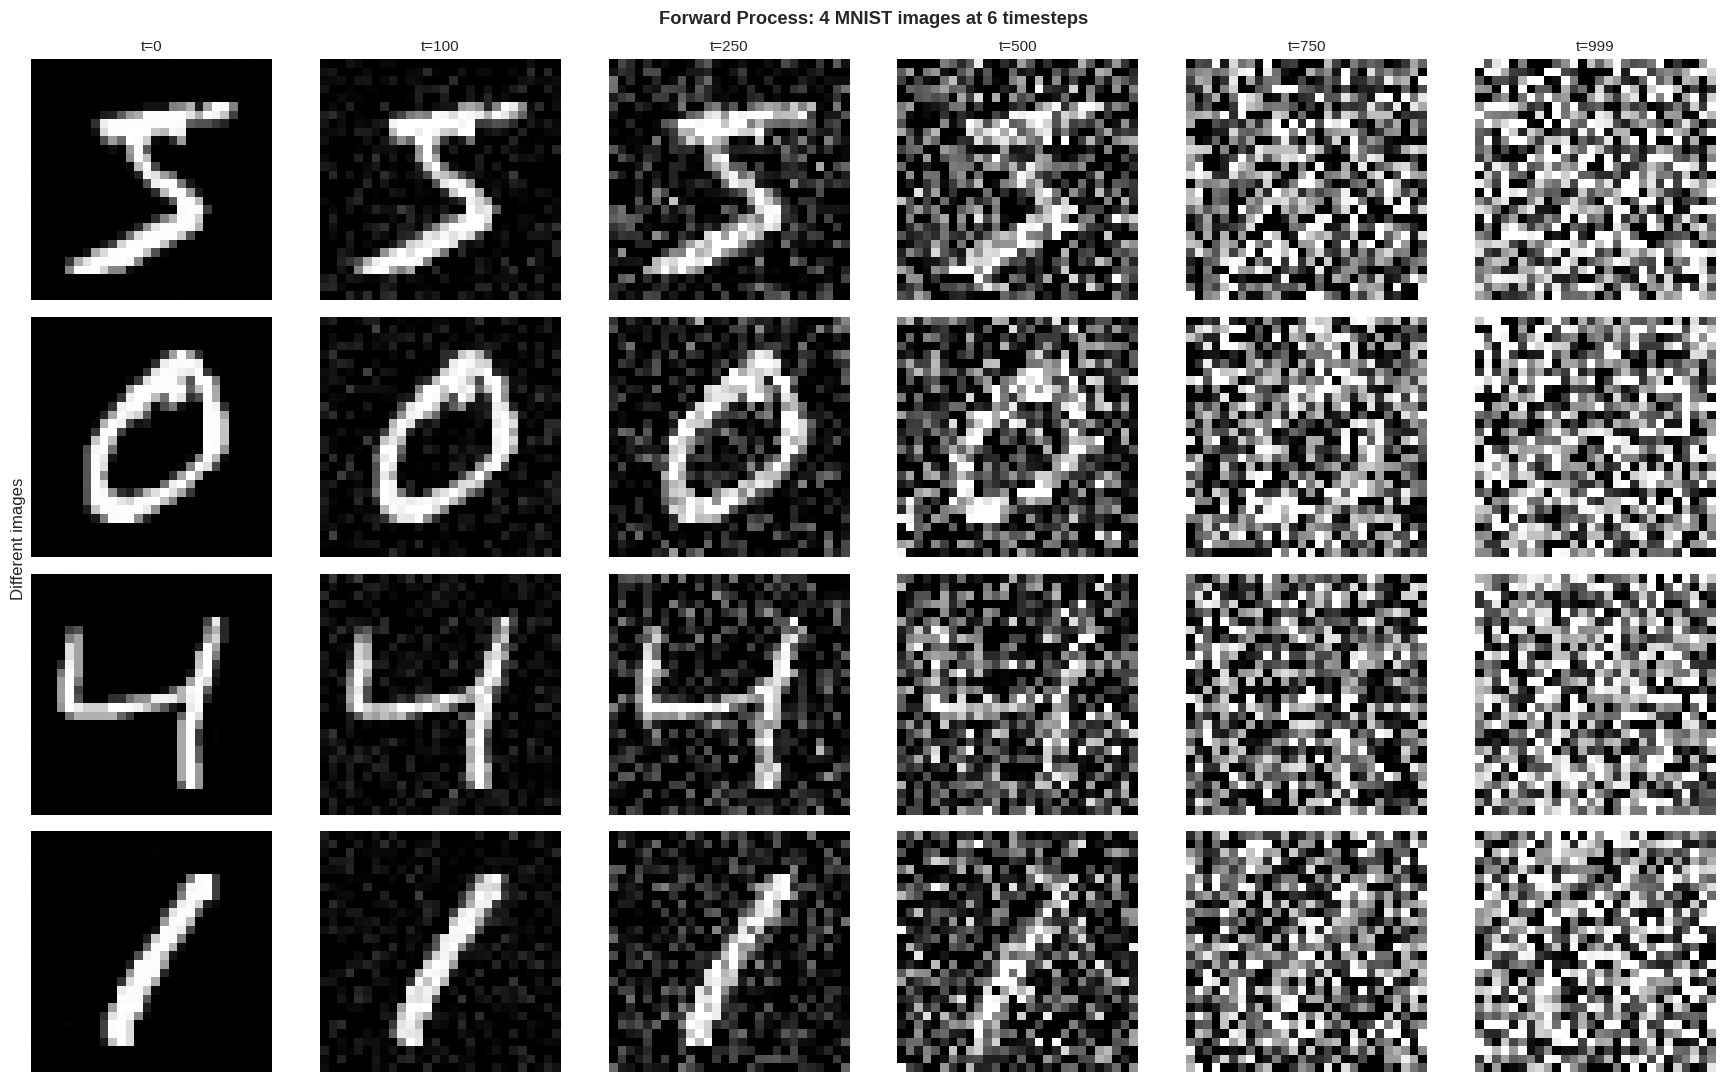

In [6]:
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    s  = extract(sqrt_a_bar,     t, x0.shape)
    nm = extract(sqrt_one_minus, t, x0.shape)
    return s * x0 + nm * noise, noise

# Show 4 MNIST images × 6 timesteps
show_imgs = torch.stack([train_ds[i][0] for i in range(4)]).to(DEVICE)
ts_show   = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(4, 6, figsize=(16, 10))
for row in range(4):
    x0_i = show_imgs[row:row+1]
    for col, t_val in enumerate(ts_show):
        t_tensor = torch.tensor([t_val], device=DEVICE)
        xt, _    = q_sample(x0_i, t_tensor)
        axes[row, col].imshow(xt[0, 0].cpu(), cmap='gray', vmin=-1, vmax=1)
        if row == 0:
            axes[row, col].set_title(f't={t_val}', fontsize=10)
        axes[row, col].axis('off')

fig.text(0.01, 0.5, 'Different images', va='center', rotation=90, fontsize=11)
plt.suptitle('Forward Process: 4 MNIST images at 6 timesteps', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 4. U-Net Architecture

The U-Net takes a **noisy image** $\mathbf{x}_t$ and the **timestep** $t$ as input, and predicts the noise $\boldsymbol{\varepsilon}$.

```
Input (1, 28, 28) + timestep t
   │
   ├─ init_conv ──────────────────────────────────────────┐ (64, 28, 28)
   │                                                       │
   ├─ ResBlock(64→64) ────────────────────────────────────┤ skip1
   ├─ Downsample ──────────────────────────────────────────┤ (64, 14, 14)
   ├─ ResBlock(64→128) ───────────────────────────────────┤ skip2
   ├─ Downsample ──────────────────────────────────────────┤ (128, 7, 7)
   ├─ ResBlock(128→256) ──────────────────────────────────┤ skip3
   │                                                       │
   ├─ Mid: ResBlock + SelfAttention + ResBlock ────────────┤ (256, 7, 7)
   │                                                       │
   ├─ Upsample + ResBlock(256+256→128) ──────────────────┘
   ├─ Upsample + ResBlock(128+128→64)
   ├─ ResBlock(64+64→64)
   │
   └─ final_conv ──── Output (1, 28, 28)   predicted ε
```

**Time conditioning** uses AdaGN (Adaptive Group Norm): the time embedding modulates each residual block via learned scale and shift.

In [7]:
# ── Sinusoidal time embedding ────────────────────────────────────────────────
class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device   = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)   # (B, dim)

# ── Residual block with time-based AdaGN ─────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, dropout=0.1):
        super().__init__()
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch * 2))
        self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.drop  = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.res   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act   = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        # AdaGN: scale-shift from time embedding
        t_out  = self.time_proj(t_emb)          # (B, 2*out_ch)
        scale, shift = t_out.chunk(2, dim=1)
        h = self.act(self.norm2(h) * (1 + scale[:, :, None, None]) + shift[:, :, None, None])
        h = self.drop(h)
        h = self.conv2(h)
        return h + self.res(x)

# ── Self-attention block ──────────────────────────────────────────────────────
class SelfAttention(nn.Module):
    def __init__(self, ch, n_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(min(8, ch), ch)
        self.qkv  = nn.Conv1d(ch, ch * 3, 1)
        self.proj = nn.Conv1d(ch, ch, 1)
        self.n_heads = n_heads
        self.scale   = (ch // n_heads) ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).reshape(B, C, H * W)
        qkv = self.qkv(h).reshape(B, 3, self.n_heads, C // self.n_heads, H * W)
        q, k, v = qkv.unbind(1)                           # each (B, heads, head_dim, HW)
        attn = torch.softmax(torch.einsum('bhdi,bhdj->bhij', q, k) * self.scale, dim=-1)
        out  = torch.einsum('bhij,bhdj->bhdi', attn, v).reshape(B, C, H * W)
        return self.proj(out).reshape(B, C, H, W) + x

print('Building blocks defined.')

Building blocks defined.


In [8]:
# ── Full U-Net ────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_ch=1, base_dim=64, t_emb_dim=256):
        super().__init__()
        d  = base_dim
        d2 = d * 2
        d4 = d * 4

        # Time embedding: sinusoidal → linear → GELU → linear
        self.time_mlp = nn.Sequential(
            SinusoidalEmbedding(d),
            nn.Linear(d, t_emb_dim),
            nn.GELU(),
            nn.Linear(t_emb_dim, t_emb_dim)
        )

        # Encoder
        self.init_conv = nn.Conv2d(in_ch, d, 3, padding=1)

        self.down1 = ResBlock(d,  d,  t_emb_dim)    # (d,  28, 28)
        self.pool1 = nn.MaxPool2d(2)                 # (d,  14, 14)
        self.down2 = ResBlock(d,  d2, t_emb_dim)    # (d2, 14, 14)
        self.pool2 = nn.MaxPool2d(2)                 # (d2,  7,  7)
        self.down3 = ResBlock(d2, d4, t_emb_dim)    # (d4,  7,  7)

        # Bottleneck
        self.mid1  = ResBlock(d4, d4, t_emb_dim)
        self.mid_attn = SelfAttention(d4)
        self.mid2  = ResBlock(d4, d4, t_emb_dim)

        # Decoder (skip connections concatenated)
        self.up3    = nn.ConvTranspose2d(d4, d4, 2, stride=2)   # (d4, 14, 14)
        self.dec3   = ResBlock(d4 + d2, d2, t_emb_dim)
        self.up2    = nn.ConvTranspose2d(d2, d2, 2, stride=2)   # (d2, 28, 28)
        self.dec2   = ResBlock(d2 + d,  d,  t_emb_dim)
        self.dec1   = ResBlock(d  + d,  d,  t_emb_dim)

        # Output head
        self.out = nn.Sequential(
            nn.GroupNorm(min(8, d), d),
            nn.SiLU(),
            nn.Conv2d(d, in_ch, 1)
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)              # (B, t_emb_dim)

        # Encoder
        x0 = self.init_conv(x)               # (B, d,  28, 28)
        x1 = self.down1(x0, t_emb)           # (B, d,  28, 28)  — skip1
        x2 = self.down2(self.pool1(x1), t_emb) # (B, d2, 14, 14)  — skip2
        x3 = self.down3(self.pool2(x2), t_emb) # (B, d4,  7,  7)

        # Bottleneck
        x3 = self.mid1(x3, t_emb)
        x3 = self.mid_attn(x3)
        x3 = self.mid2(x3, t_emb)

        # Decoder
        h = self.up3(x3)                     # (B, d4, 14, 14)
        h = self.dec3(torch.cat([h, x2], dim=1), t_emb)  # (B, d2, 14, 14)
        h = self.up2(h)                      # (B, d2, 28, 28)
        h = self.dec2(torch.cat([h, x1], dim=1), t_emb)  # (B, d,  28, 28)
        h = self.dec1(torch.cat([h, x0], dim=1), t_emb)  # (B, d,  28, 28)

        return self.out(h)                   # (B, in_ch, 28, 28)

# Sanity check
model = UNet(in_ch=CHANNELS, base_dim=MODEL_DIM).to(DEVICE)
test_x = torch.randn(2, CHANNELS, IMG_SIZE, IMG_SIZE, device=DEVICE)
test_t = torch.randint(0, T_STEPS, (2,), device=DEVICE)
test_out = model(test_x, test_t)
print(f'Input shape : {tuple(test_x.shape)}')
print(f'Output shape: {tuple(test_out.shape)}')
assert test_out.shape == test_x.shape, 'Shape mismatch!'

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Input shape : (2, 1, 28, 28)
Output shape: (2, 1, 28, 28)
Total parameters: 5,805,889


---
## 5. Training

The training objective is simple: predict the noise $\boldsymbol{\varepsilon}$ that was added to $\mathbf{x}_0$:

$$\mathcal{L} = \mathbb{E}_{\mathbf{x}_0 \sim q,\; t \sim \mathcal{U}[1,T],\; \boldsymbol{\varepsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I})} \left[\|\boldsymbol{\varepsilon} - \boldsymbol{\varepsilon}_\theta(\mathbf{x}_t, t)\|^2\right]$$

**Algorithm (one gradient step):**
1. Sample $\mathbf{x}_0 \sim p_{\text{data}}$
2. Sample $t \sim \mathcal{U}\{1,\ldots,T\}$
3. Sample $\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$
4. Compute $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\boldsymbol{\varepsilon}$
5. Minimise $\|\boldsymbol{\varepsilon} - \boldsymbol{\varepsilon}_\theta(\mathbf{x}_t, t)\|^2$

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    for x0, _ in tqdm(train_dl, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=False):
        x0    = x0.to(DEVICE)
        t     = torch.randint(0, T_STEPS, (x0.size(0),), device=DEVICE)
        noise = torch.randn_like(x0)
        xt, _ = q_sample(x0, t, noise)

        pred_noise = model(xt, t)
        loss       = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dl)
    train_losses.append(avg_loss)
    scheduler.step()

    if (epoch + 1) % 5 == 0:
        ckpt = os.path.join(SAVE_DIR, f'ckpt_epoch{epoch+1:03d}.pt')
        torch.save(model.state_dict(), ckpt)
        print(f'Epoch {epoch+1:3d} | Loss: {avg_loss:.5f} | Saved {ckpt}')

print('Training complete.')

Epoch   5 | Loss: 0.04309 | Saved ./ddpm_results/ckpt_epoch005.pt
Epoch  10 | Loss: 0.03948 | Saved ./ddpm_results/ckpt_epoch010.pt
Epoch  15 | Loss: 0.03825 | Saved ./ddpm_results/ckpt_epoch015.pt
Epoch  20 | Loss: 0.03759 | Saved ./ddpm_results/ckpt_epoch020.pt
Training complete.


Final loss: 0.03759


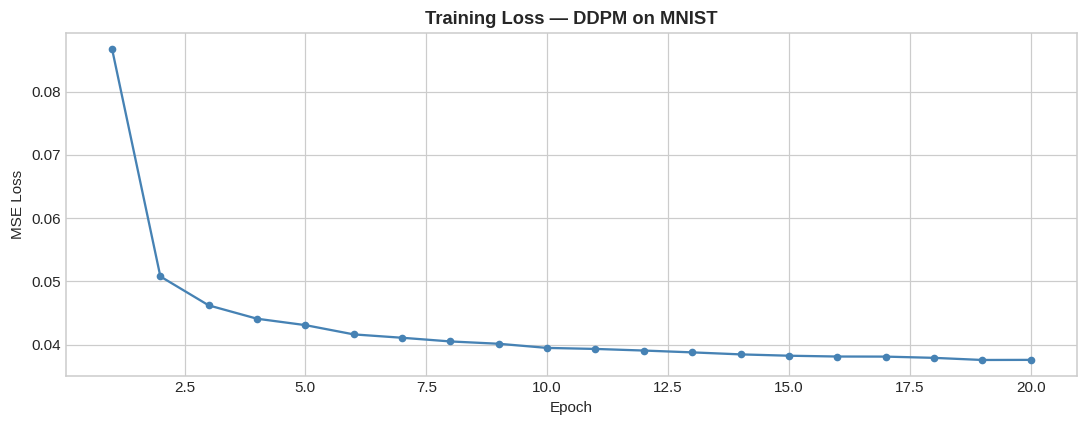

In [10]:
# Loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', markersize=4, color='steelblue')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss — DDPM on MNIST', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Final loss: {train_losses[-1]:.5f}')

---
## 6. Sampling — DDPM Reverse Process

Starting from $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0},\mathbf{I})$, iterate backward from $t=T$ to $t=0$:

$$\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\boldsymbol{\varepsilon}_\theta(\mathbf{x}_t, t)\right) + \sqrt{\tilde{\beta}_t}\,\mathbf{z}, \quad \mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})\text{ if }t>1$$

This runs **1 000 network evaluations** per sample — slow but simple. DDIM and DPM-Solver reduce this to ~20–50 steps.

In [11]:
@torch.no_grad()
def ddpm_sample(model, n=16, channels=1, size=28, save_trajectory=False):
    model.eval()
    x = torch.randn(n, channels, size, size, device=DEVICE)
    trajectory = [x.cpu().clone()] if save_trajectory else None
    checkpoints = set(range(0, T_STEPS, T_STEPS // 10)) | {0}

    for t_idx in tqdm(reversed(range(T_STEPS)), desc='Sampling', total=T_STEPS, leave=False):
        t_batch  = torch.full((n,), t_idx, device=DEVICE, dtype=torch.long)
        eps_pred = model(x, t_batch)

        alpha_t  = alphas[t_idx]
        a_bar_t  = alphas_cumprod[t_idx]
        beta_t   = betas[t_idx]
        coeff    = beta_t / sqrt_one_minus[t_idx]
        mean     = sqrt_recip_alpha[t_idx] * (x - coeff * eps_pred)

        if t_idx > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(posterior_var[t_idx]) * noise
        else:
            x = mean

        if save_trajectory and t_idx in checkpoints:
            trajectory.append(x.cpu().clone())

    return x.cpu(), trajectory

samples, _ = ddpm_sample(model, n=16)
print(f'Generated {samples.shape[0]} samples, shape: {tuple(samples.shape)}')

Generated 16 samples, shape: (16, 1, 28, 28)


Saved to ./ddpm_results


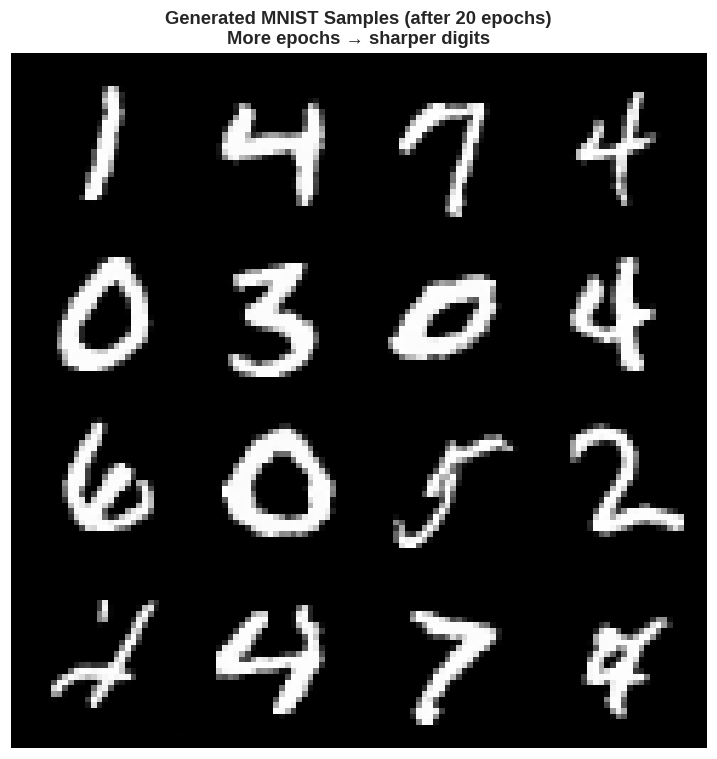

In [12]:
# Show generated samples in a 4×4 grid
grid = torchvision.utils.make_grid(samples, nrow=4, normalize=True, value_range=(-1, 1))
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
ax.axis('off')
ax.set_title(f'Generated MNIST Samples (after {NUM_EPOCHS} epochs)\nMore epochs → sharper digits', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
fig.savefig(os.path.join(SAVE_DIR, 'generated_samples.png'), dpi=150, bbox_inches='tight')
print('Saved to', SAVE_DIR)

Trajectory has 11 snapshots.


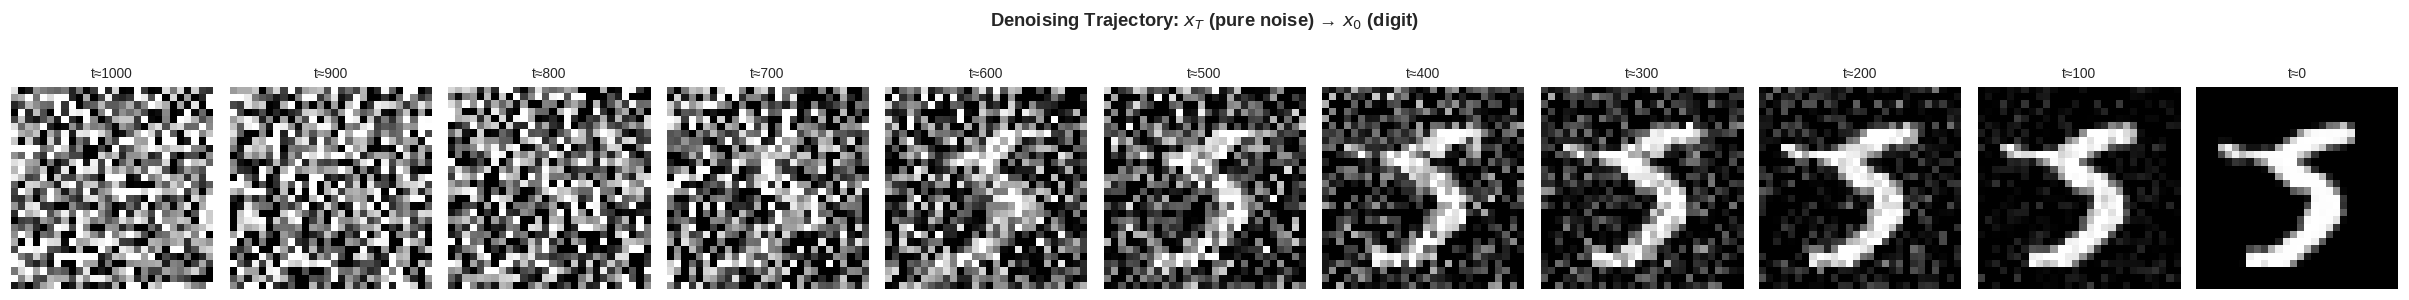

In [13]:
# ── Denoising trajectory for one sample ─────────────────────────────────────
_, trajectory = ddpm_sample(model, n=1, save_trajectory=True)
print(f'Trajectory has {len(trajectory)} snapshots.')

fig, axes = plt.subplots(1, len(trajectory), figsize=(22, 3))
for col, snap in enumerate(trajectory):
    axes[col].imshow(snap[0, 0].numpy(), cmap='gray', vmin=-1, vmax=1)
    step = T_STEPS - col * (T_STEPS // 10) if col < len(trajectory)-1 else 0
    axes[col].set_title(f't≈{step}', fontsize=9)
    axes[col].axis('off')

plt.suptitle('Denoising Trajectory: $x_T$ (pure noise) → $x_0$ (digit)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

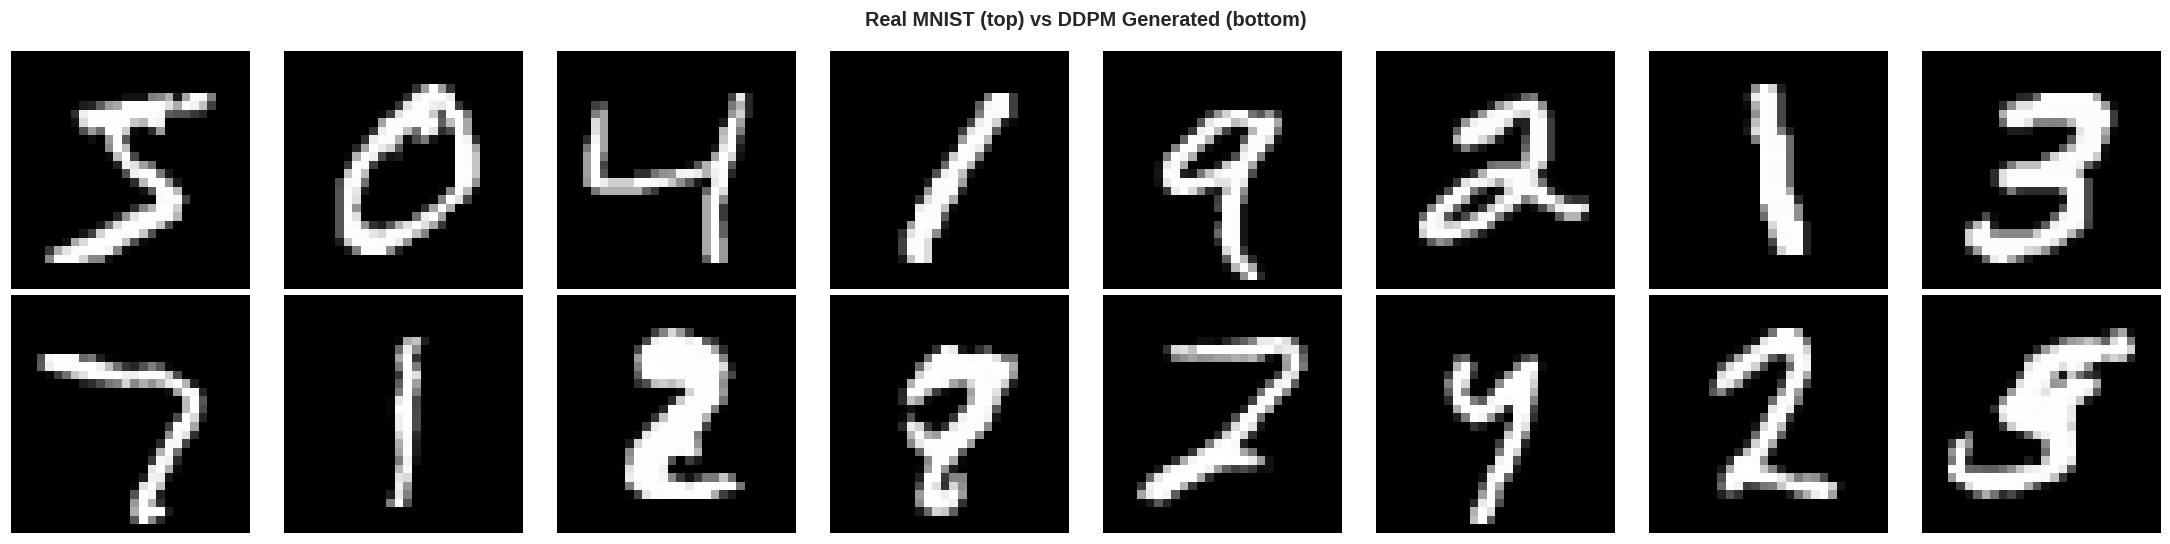

In [14]:
# ── Compare real vs generated ─────────────────────────────────────────────────
real_imgs = torch.stack([train_ds[i][0] for i in range(16)])
fake_imgs, _ = ddpm_sample(model, n=16)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for col in range(8):
    axes[0, col].imshow(real_imgs[col, 0].numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[0, col].axis('off')
    if col == 0: axes[0, col].set_ylabel('Real', fontsize=11, fontweight='bold')

    axes[1, col].imshow(fake_imgs[col, 0].numpy(), cmap='gray', vmin=-1, vmax=1)
    axes[1, col].axis('off')
    if col == 0: axes[1, col].set_ylabel('Generated', fontsize=11, fontweight='bold')

plt.suptitle('Real MNIST (top) vs DDPM Generated (bottom)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Summary & Next Steps

**What we built:**
- Cosine noise schedule with precomputed statistics
- Closed-form forward sampling at any timestep
- U-Net with sinusoidal time embeddings, AdaGN conditioning, self-attention in bottleneck
- Simple MSE noise prediction loss
- Full DDPM reverse sampler (1 000 denoising steps)

**Limitations of this implementation:**
- 1 000 sampling steps → slow ($\approx$ 30s on CPU for 16 images)
- Unconditional generation only
- 28×28 grayscale only

**Extensions to explore:**

| Extension | Description |
|---|---|
| **DDIM** | Deterministic sampler, 20–50 steps |
| **Classifier-free guidance** | Class-conditional generation, strength $w$ |
| **LDM** | Encode to latent space (VAE), diffuse there |
| **Transformer U-Net (DiT)** | Replace conv blocks with attention |
| **Larger datasets** | CIFAR-10, CelebA, ImageNet |
| **Diffusion Policy** | Replace image data with robot trajectories |